In [151]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# Cargar el dataset
df = sns.load_dataset('penguins')

In [152]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


#**Parte A**

¿Cuántas filas y columnas tiene el dataset?

In [ ]:
print('la cantidad de filas es',len(df.loc[:]))

la cantidad de filas es 344


In [ ]:
print('la cantidad de columnas es',len(df.columns))

la cantidad de columnas es 7


¿Qué variables son numéricas y cuáles categóricas?

In [ ]:
df_num = df.select_dtypes(include=['number'])
df_cat = df.select_dtypes(include=['object', 'category'])
print('Las variables numericas son:',df_num.columns)
print('Las variables categoricas son:',df_cat.columns)

Las variables numericas son: Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object')
Las variables categoricas son: Index(['species', 'island', 'sex'], dtype='object')


¿Cuántos valores faltantes hay por columna?

In [ ]:
print(df.isna().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


¿Existen filas duplicadas?

In [ ]:
print('Hay',df.duplicated().sum(),'filas duplicadas')

Hay 0 filas duplicadas


¿Qué variables tienen baja cardinalidad?

In [ ]:
print(df.nunique())

species                3
island                 3
bill_length_mm       164
bill_depth_mm         80
flipper_length_mm     55
body_mass_g           94
sex                    2
dtype: int64


#**Parte B**

Descripción 6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.

In [ ]:
print('La media es')
print(df_num.mean())


La media es
bill_length_mm         43.921930
bill_depth_mm          17.151170
flipper_length_mm     200.915205
body_mass_g          4201.754386
dtype: float64


In [ ]:
print('La mediana es')
print(df_num.median())


La mediana es
bill_length_mm         44.45
bill_depth_mm          17.30
flipper_length_mm     197.00
body_mass_g          4050.00
dtype: float64


In [ ]:
print('La desviacion estandar es')
print(df_num.std())


La desviacion estandar es
bill_length_mm         5.459584
bill_depth_mm          1.974793
flipper_length_mm     14.061714
body_mass_g          801.954536
dtype: float64


In [ ]:
print('El rango intercuartilico es')
q1_col = df_num.quantile(0.25)
q3_col = df_num.quantile(0.75)
iqr_col = q3_col - q1_col
print(iqr_col)

El rango intercuartilico es
bill_length_mm          9.275
bill_depth_mm           3.100
flipper_length_mm      23.000
body_mass_g          1200.000
dtype: float64


7) Para cada variable categórica, reporte conteos y porcentajes.

In [ ]:
df_cat.value_counts()

species    island     sex   
Gentoo     Biscoe     Male      61
                      Female    58
Chinstrap  Dream      Female    34
                      Male      34
Adelie     Dream      Male      28
                      Female    27
           Torgersen  Female    24
                      Male      23
           Biscoe     Male      22
                      Female    22
Name: count, dtype: int64

In [ ]:
df_cat.value_counts(normalize=True) * 100

species    island     sex   
Gentoo     Biscoe     Male      18.318318
                      Female    17.417417
Chinstrap  Dream      Female    10.210210
                      Male      10.210210
Adelie     Dream      Male       8.408408
                      Female     8.108108
           Torgersen  Female     7.207207
                      Male       6.906907
           Biscoe     Male       6.606607
                      Female     6.606607
Name: proportion, dtype: float64

8) Construya tablas cruzadas para pares de variables categóricas relevantes.

In [ ]:
print('Tabla de especie y sexo')
print(pd.crosstab(df_cat.species,df_cat.sex))


Tabla de especie y sexo
sex        Female  Male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61


In [ ]:
print('Tabla de isla y sexo')
print(pd.crosstab(df_cat.island,df_cat.sex))


Tabla de isla y sexo
sex        Female  Male
island                 
Biscoe         80    83
Dream          61    62
Torgersen      24    23


In [ ]:
print('Tabla de especie e isla')
print(pd.crosstab(df_cat.species,df_cat.island))

Tabla de especie e isla
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

In [ ]:
df_num.corr(method='pearson')

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


In [ ]:
df_num.corr(method='spearman')

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.221749,0.672772,0.583800
bill_depth_mm,-0.221749,1.000000,-0.523267,-0.432372
flipper_length_mm,0.672772,-0.523267,1.000000,0.839974
body_mass_g,0.583800,-0.432372,0.839974,1.000000


#**Parte C**

Visualización 10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.

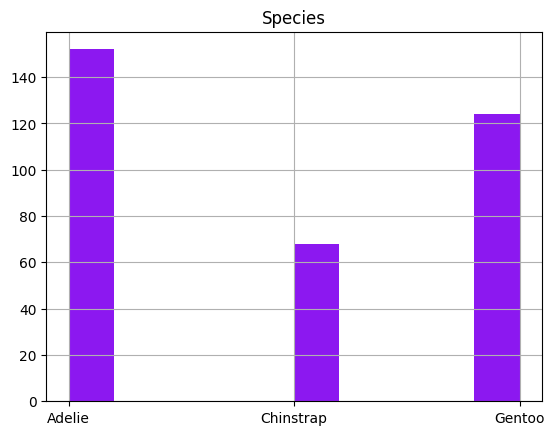

In [ ]:
plt.hist(df_cat.species,color='#8C18F0')
plt.title('Species')
plt.grid()
plt.show()

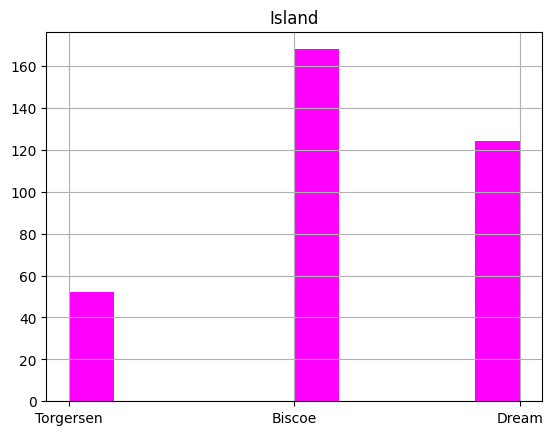

In [ ]:
plt.hist(df_cat.island,color='magenta')
plt.title('Island')
plt.grid()
plt.show()

11) Genere histogramas para variables numéricas y describa su forma.

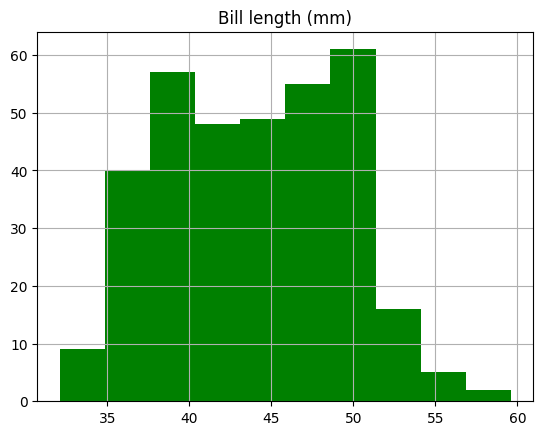

In [ ]:
plt.hist(df_num.bill_length_mm,color='green')
plt.title('Bill length (mm)')
plt.grid()
plt.show()

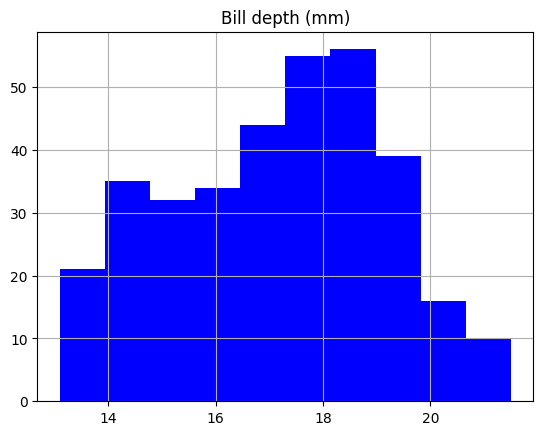

In [ ]:
plt.hist(df_num.bill_depth_mm,color='blue')
plt.title('Bill depth (mm)')
plt.grid()
plt.show()

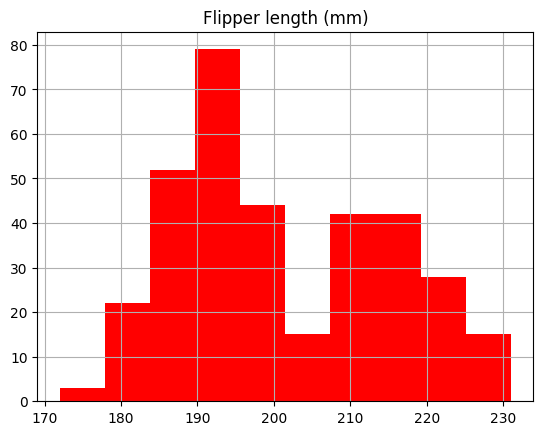

In [ ]:
plt.hist(df_num.flipper_length_mm,color='red')
plt.title('Flipper length (mm)')
plt.grid()
plt.show()

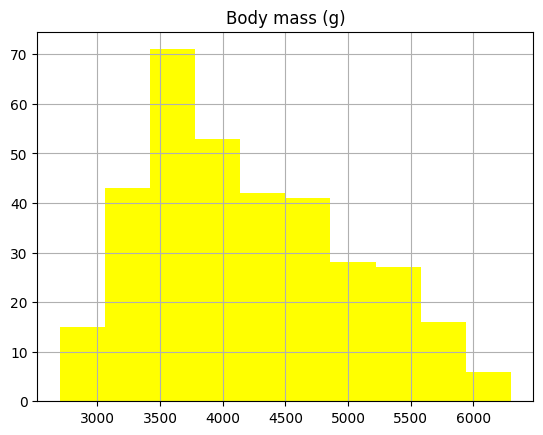

In [ ]:
plt.hist(df_num.body_mass_g,color='yellow')
plt.title('Body mass (g)')
plt.grid()
plt.show()
#

12) Genere boxplots de una variable numérica por categoría (p. ej., bill_length_mm por species)

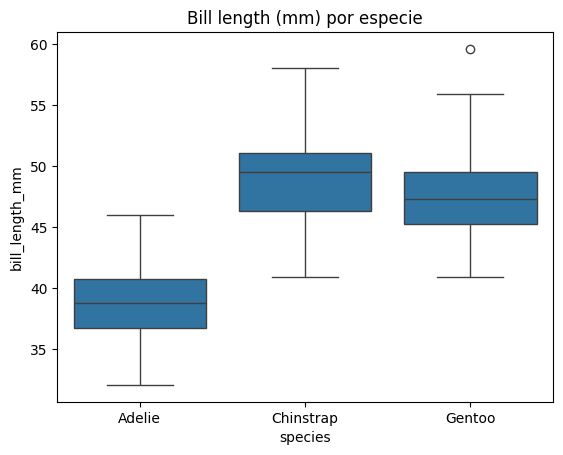

In [ ]:
sns.boxplot(x='species',y='bill_length_mm',data=df)
plt.title('Bill length (mm) por especie')
plt.show()

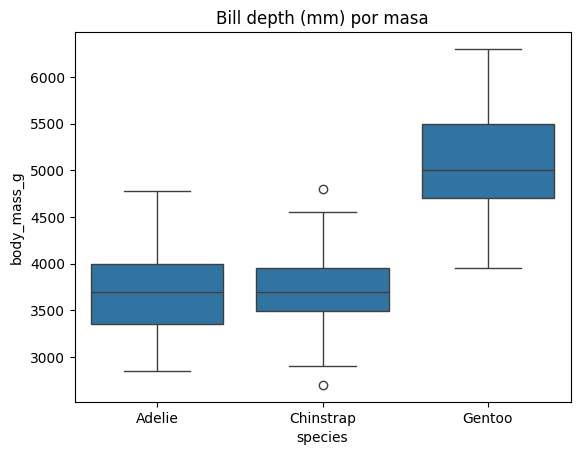

In [ ]:
sns.boxplot(x='species',y='body_mass_g',data=df)
plt.title('Bill depth (mm) por masa')
plt.show()
#

13) Genere un scatter entre dos variables numéricas y coloree por una categoría.

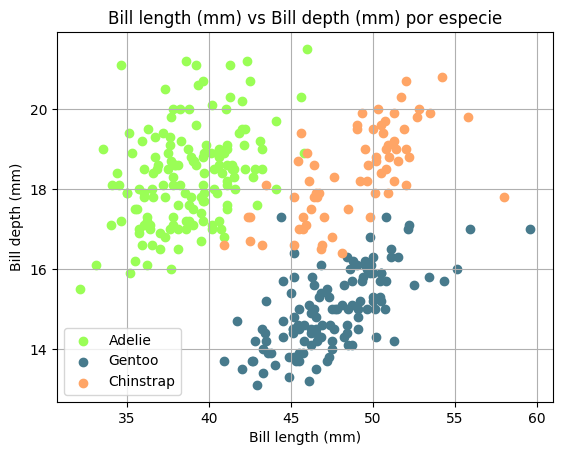

In [ ]:
plt.scatter(x='bill_length_mm',y='bill_depth_mm',c='#9AFE56',data=df.loc[df.species=='Adelie'])
plt.scatter(x='bill_length_mm',y='bill_depth_mm',c='#477A8C',data=df.loc[df.species=='Gentoo'])
plt.scatter(x='bill_length_mm',y='bill_depth_mm',c='#FFA566',data=df.loc[df.species=='Chinstrap'])
plt.legend(['Adelie','Gentoo','Chinstrap'])
plt.xlabel('Bill length (mm)')
plt.ylabel('Bill depth (mm)')
plt.title('Bill length (mm) vs Bill depth (mm) por especie')
plt.grid()
plt.show()
#

14) Genere un heatmap de correlación.

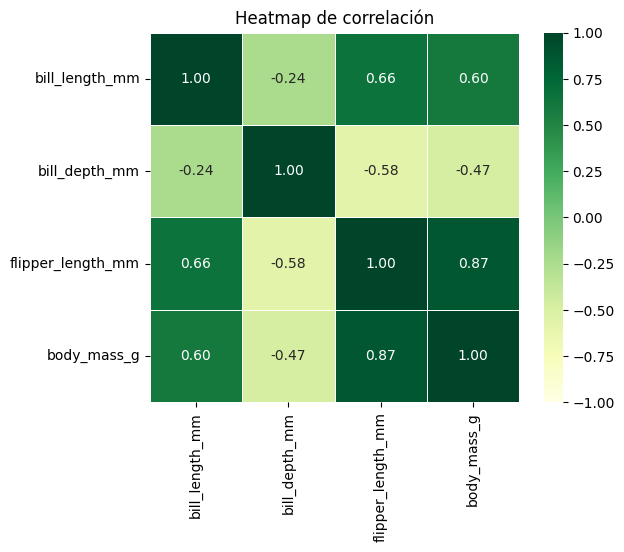

In [ ]:
sns.heatmap(df_num.corr('pearson'),annot=True,cmap='YlGn',    fmt=".2f",          vmin=-1, vmax=1, square=True,         linewidths=0.5  )
plt.title('Heatmap de correlación')
plt.show()

#**Parte D**

15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos



1.   ¿Está la longitud del ala relacionada con la masa corporal?
2.   ¿El tamaño del pico difiere por especie?
3.   ¿La especie se asocia con la isla?



#**Parte D**

In [ ]:
from scipy import stats


¿Está la longitud del ala relacionada con la masa corporal de acuerdo a una prueba de t-student?

In [154]:
stat, p_valor = stats.ttest_ind(df.flipper_length_mm, df.body_mass_g, nan_policy='omit')

print(f"Estadístico t: {stat:.4f}")
print(f"p-valor: {p_valor:.4f}")

Estadístico t: -92.2460
p-valor: 0.0000


El valor p muestra una relación estadística entre las dos variables con un error $\alpha=0.001$

¿El tamaño del pico difiere por especie de acuerdo a una prueba ANOVA?

In [162]:
df_clean = df.dropna(subset=['bill_length_mm', 'species'])
adelie = df_clean[df_clean['species'] == 'Adelie']['bill_length_mm']
chinstrap = df_clean[df_clean['species'] == 'Chinstrap']['bill_length_mm']
gentoo = df_clean[df_clean['species'] == 'Gentoo']['bill_length_mm']

# 4. Realizar la prueba ANOVA
f_stat, p_value = stats.f_oneway(adelie, chinstrap, gentoo)
print(f"Estadístico F: {f_stat:.4f}")
print(f"p-valor: {p_value:.4f}")

Estadístico F: 410.6003
p-valor: 0.0000


Sí se puede concluir que hay una diferencia en el tamaño de pico y al menos dos especies, debido al valor del valor p

¿La especie se asocia con la isla mediante una prueba de $\chi^2$?

In [163]:
# 1. Creamos la tabla de contingencia (conteos cruzados)
tabla_contingencia = pd.crosstab(df['species'], df['island'])

# 2. Ejecutamos la prueba de Chi-Cuadrado
chi2, p_valor, dof, expected = stats.chi2_contingency(tabla_contingencia)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"p-valor: {p_valor:.4f}")

Estadístico Chi2: 299.5503
p-valor: 0.0000


Se muestra que sí hay una relación entre las variables debido al valor p igual a cero.

#**Parte F**

**Conclusiones**

Se puede concluir que hay una relación entre la longitud de ala y la masa corporal, de la misma forma se puede concluir que cada especie tiene una diferencia de tamaño de pico significativa, y además la especie depende de la isla onde habita, siendo la especie Aelie la única que habita en todas las islas.

También se puede observar gracias al conteo realizado que hay una paridad notable entre los sexos para cada especie, siendo la especie Gentoo la que presenta más disparidad. También se concluye que la especie con más ejemplares es la Adelie, mientras que la isla más poblada es la isla Biscoe, esto de acuerdo a los histográmas.

Por último unas futuras pruebas realizar son si hay una relación entre la longitud dwl pico y el grosor de este, o encontrar que especie tiene el tamaño de ala más grande, buscar si las diferencias físicas cambian bastante de acuerdo al sexo o encontrar si una distribución que se acomode a los datos.